In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Data preprocessing

In [2]:
df_train = pd.read_csv('breastCancerTrain.csv', sep = '\t')
df_train.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,,gender,Bratio
0,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,F,0.162878,NaN
1,84300903,M,19.69,21.25,130,1203,0.1096,0.1599,0.1974,0.1279,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.00615,0.04006,0.03832,0.02058,0.0225,0.004571,23.57,25.53,152.5,1709,0.1444,0.4245,0.4504,0.243,0.3613,0.08758,F,0.751106,NaN
2,84348301,M,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.09744,0.4956,1.156,3.445,27.23,0.00911,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.5,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,F,0.465537,NaN
3,84358402,M,20.29,14.34,135.1,1297,0.1003,0.1328,0.198,0.1043,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.01149,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.2,1575,0.1374,0.205,0.4,0.1625,0.2364,0.07678,F,0.969993,NaN
4,844359,M,18.25,-19.98,119.6,1040,0.09463,0.109,0.1127,0.074,0.1794,0.05742,?,0.7732,3.18,53.91,0.004314,0.01382,0.02254,0.01039,0.01369,0.002179,22.88,27.66,153.2,1606,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,F,0.552544,NaN


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       390 non-null    object 
 1   diagnosis                390 non-null    object 
 2   radius_mean              390 non-null    object 
 3   texture_mean             390 non-null    object 
 4   perimeter_mean           390 non-null    object 
 5   area_mean                390 non-null    object 
 6   smoothness_mean          390 non-null    object 
 7   compactness_mean         390 non-null    object 
 8   concavity_mean           390 non-null    object 
 9   concave points_mean      390 non-null    object 
 10  symmetry_mean            390 non-null    object 
 11  fractal_dimension_mean   390 non-null    object 
 12  radius_se                390 non-null    object 
 13  texture_se               390 non-null    object 
 14  perimeter_se             3

In [4]:
df_train.drop('Bratio', axis=1, inplace=True)                   # Bratio all null values, completely irrelevant column
df_train.replace(to_replace='?', value=np.nan, inplace=True)    # replace ? entries with NaN
df_train.rename(columns = {"gender": "Bratio", " ": "gender"}, inplace=True)  # rename mis-labelled columns 

df_train['diagnosis'].value_counts()

diagnosis
B    246
M    144
Name: count, dtype: int64

In [5]:
training = df_train.drop(['diagnosis', 'gender'], axis=1).astype('float64')  # temporarily drop diagnosis and gender (only features that should be objects) and changes all other features into floats
training[['diagnosis','gender']] = df_train[['diagnosis','gender']]  # put diagnosis and gender (objects) back
training.drop('id', axis=1, inplace=True)   # drop id (column of unique values, not informative).

#train.head()

In [6]:
# Similarly for the test set
df_test = pd.read_csv('breastCancerTest.csv', sep='\t')
df_test.drop('Bratio', axis=1, inplace=True)
df_test.replace(to_replace='?', value=np.nan, inplace=True)
df_test.rename(columns={"gender":"Bratio", " ":"gender"}, inplace=True)

df_test['diagnosis'].value_counts()

diagnosis
B    111
M     68
Name: count, dtype: int64

In [7]:
testing = df_test.drop(['diagnosis','gender'], axis=1).astype('float64')
testing[['diagnosis','gender']] = df_test[['diagnosis','gender']]
testing.drop('id', axis=1, inplace=True)

#test.head()

#### Prepare training and test datasets

In [8]:
trainset = training.drop(['gender','diagnosis'], axis=1).copy()  # drop object dtype columns, in preparation for imputing.
testset = testing.drop(['diagnosis','gender'], axis=1).copy()

train_target = training['diagnosis'].copy()  # keep separate
test_target = testing['diagnosis'].copy()

### Imputing for missing values

A relatively small dataset, therefore instances with missing values cannot just be dropped. 
Better to impute with representative values.

In [9]:
#trainset.isna().sum()
#testset.isna().sum()

In [10]:
from sklearn.impute import SimpleImputer

In [11]:
train_imputer = SimpleImputer(missing_values=np.nan, strategy='median')  # using median as representative value (not biased by outliers)
test_imputer = SimpleImputer(missing_values=np.nan, strategy='median')

train_imputer.fit(trainset)
test_imputer.fit(testset)

SimpleImputer(strategy='median')

In [12]:
imputed_train = pd.DataFrame(train_imputer.transform(trainset), columns = trainset.columns)
imputed_test =  pd.DataFrame(test_imputer.transform(testset), columns = testset.columns)

In [13]:
# putting back the object dtypes columns (diagnosis), no need to put gender column back in (all F entries, as expected, not informative)
imputed_train_dataset = imputed_train.copy()
imputed_train_dataset['diagnosis'] = train_target  
imputed_test_dataset = imputed_test.copy()
imputed_test_dataset['diagnosis'] = test_target

In [14]:
train = imputed_train_dataset.copy()
test = imputed_test_dataset.copy()

train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Bratio,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.2776,0.3001,0.1471,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.162878,M
1,19.69,21.25,130.00,1203.0,0.10960,0.1599,0.1974,0.1279,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.751106,M
2,11.42,20.38,77.58,386.1,0.14250,0.2839,0.2414,0.1052,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0.465537,M
3,20.29,14.34,135.10,1297.0,0.10030,0.1328,0.1980,0.1043,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0.969993,M
4,18.25,-19.98,119.60,1040.0,0.09463,0.1090,0.1127,0.0740,0.1794,0.05742,0.3147,0.7732,3.180,53.91,0.004314,0.01382,0.02254,0.01039,0.01369,0.002179,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0.552544,M


### SMOTE for handling the imbalanced classes

In [15]:
train['diagnosis'].value_counts()
#test['diagnosis'].value_counts()

diagnosis
B    246
M    144
Name: count, dtype: int64

In [16]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report,confusion_matrix

In [17]:
X_train = train.drop('diagnosis', axis=1)
y_train = train['diagnosis']

In [18]:
sm = SMOTE(random_state=2)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train) 

print("Before oversampling, '1' label counts: {}".format(sum(y_train=='M')))
print("Before oversampling, '0' label counts: {}".format(sum(y_train=='B')))
print("After oversampling, '1' label counts: {}".format(sum(y_train_sm=='M')))
print("After oversampling, '0' label counts: {}".format(sum(y_train_sm=='B')))

print("\nClasses are now balanced after applying SMOTE")

Before oversampling, '1' label counts: 144
Before oversampling, '0' label counts: 246
After oversampling, '1' label counts: 246
After oversampling, '0' label counts: 246

Classes are now balanced after applying SMOTE


C:\Users\ayabo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ayabo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\ayabo\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ayabo\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

## Decision Tree Induction

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [20]:
# As was done for the training set during SMOTE
X_test = test.drop('diagnosis', axis=1)
y_test = test['diagnosis']

In [21]:
tree = DecisionTreeClassifier(criterion='entropy', random_state=123)

#### Training set

In [22]:
tree.fit(X_train_sm, y_train_sm)

DecisionTreeClassifier(criterion='entropy', random_state=123)

In [23]:
train_pred = tree.predict(X_train_sm)

In [24]:
cm_train = confusion_matrix(y_train_sm, train_pred)
print(cm_train)

[[246   0]
 [  0 246]]


In [25]:
print(classification_report(y_train_sm, train_pred))

              precision    recall  f1-score   support

           B       1.00      1.00      1.00       246
           M       1.00      1.00      1.00       246

    accuracy                           1.00       492
   macro avg       1.00      1.00      1.00       492
weighted avg       1.00      1.00      1.00       492



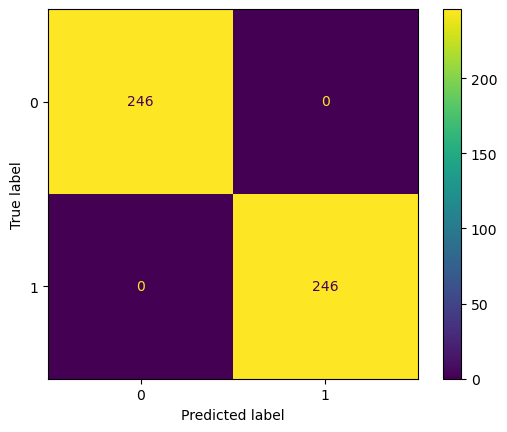

In [26]:
ConfusionMatrixDisplay(cm_train).plot()

#### Test set

In [27]:
test_pred = tree.predict(X_test)

In [28]:
cm_test = confusion_matrix(y_test, test_pred)
print(cm_test)

[[101  10]
 [  7  61]]


In [29]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           B       0.94      0.91      0.92       111
           M       0.86      0.90      0.88        68

    accuracy                           0.91       179
   macro avg       0.90      0.90      0.90       179
weighted avg       0.91      0.91      0.91       179



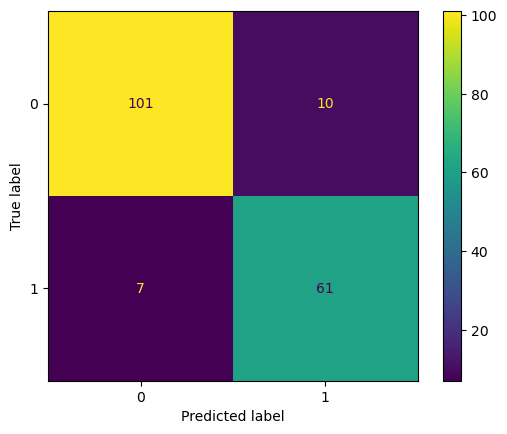

In [30]:
ConfusionMatrixDisplay(cm_test).plot()

#### Pruning (cost-complexity pruining applied)

The induced tree was overfitted 
- accuracy was 100% during training (246 TPs and 246 TNs, 0 FPs and 0 FNs) but dropped significantly during testing (7 FNs and 10 FPs)
- accuracy, precision, recall, and F1 were very high during training (all =1) but dropped significantly during testing (0.91, 0.86, 0.90, and 0.88)
- pruning is applied to properly fit the decision tree

In [31]:
path = tree.cost_complexity_pruning_path(X_train_sm, y_train_sm)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
print(ccp_alphas)

[0.         0.00659576 0.00982615 0.00986738 0.01115217 0.01214262
 0.01228017 0.01228017 0.01473419 0.01644408 0.01718555 0.01789819
 0.02036348 0.02175981 0.04942523 0.06161621 0.07552587 0.58686263]


In [32]:
trees = []
for ccp_alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=123, ccp_alpha = ccp_alpha)
    tree.fit(X_train_sm, y_train_sm)
    trees.append(tree)

Last element in the ccp_alphas was removed, as it is a trivial tree with only one node 

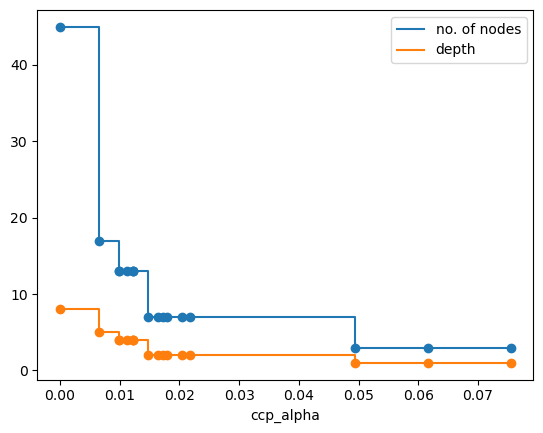

In [33]:
trees = trees[:-1]
ccp_alphas = ccp_alphas[:-1]
nodes = [tree.tree_.node_count for tree in trees]
depth = [tree.tree_.max_depth for tree in trees]
plt.scatter(ccp_alphas, nodes)
plt.scatter(ccp_alphas, depth)
plt.plot(ccp_alphas, nodes, label='no. of nodes', drawstyle='steps-post')
plt.plot(ccp_alphas, depth, label='depth', drawstyle='steps-post')
plt.legend()
plt.xlabel('ccp_alpha')
plt.show()

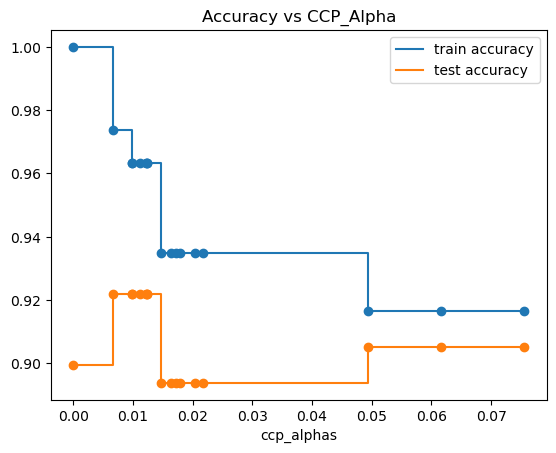

In [34]:
train_acc = []
test_acc = []
for tree in trees:
    y_train_pred = tree.predict(X_train_sm)
    y_test_pred = tree.predict(X_test)
    train_acc.append(accuracy_score(y_train_pred, y_train_sm))
    test_acc.append(accuracy_score(y_test_pred, y_test))

plt.scatter(ccp_alphas, train_acc)
plt.scatter(ccp_alphas, test_acc)
plt.plot(ccp_alphas, train_acc, label='train accuracy', drawstyle='steps-post')                  
plt.plot(ccp_alphas, test_acc, label='test accuracy', drawstyle='steps-post') 
plt.xlabel('ccp_alphas')
plt.legend()
plt.title('Accuracy vs CCP_Alpha')
plt.show()

High test and train accuracies at approximately 0.005 ccp_alpha - selected for a properly fitted tree.

In [35]:
clf = DecisionTreeClassifier(random_state=123, ccp_alpha=0.005)
clf.fit(X_train_sm, y_train_sm)
y_train_pred = clf.predict(X_train_sm)
y_test_pred = clf.predict(X_test)

print(f'Training accuracy score {accuracy_score(y_train_pred, y_train_sm)}')
print(f'Test accuracy score {accuracy_score(y_test_pred, y_test)}')

Training accuracy score 0.9776422764227642
Test accuracy score 0.9217877094972067


[[243   8]
 [  3 238]]


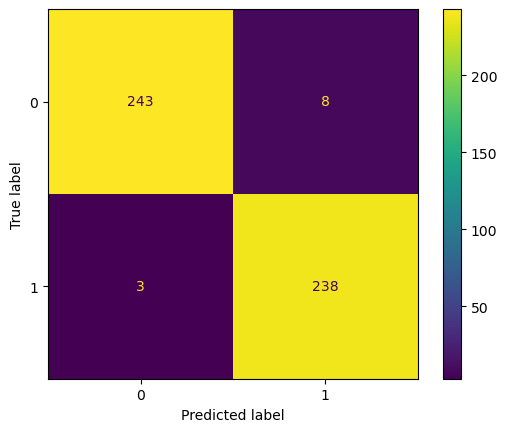

In [36]:
cm_pruned_train = confusion_matrix(y_train_pred, y_train_sm)
print(cm_pruned_train)
ConfusionMatrixDisplay(cm_pruned_train).plot()

In [37]:
print(classification_report(y_train_pred, y_train_sm))

              precision    recall  f1-score   support

           B       0.99      0.97      0.98       251
           M       0.97      0.99      0.98       241

    accuracy                           0.98       492
   macro avg       0.98      0.98      0.98       492
weighted avg       0.98      0.98      0.98       492



[[104   7]
 [  7  61]]


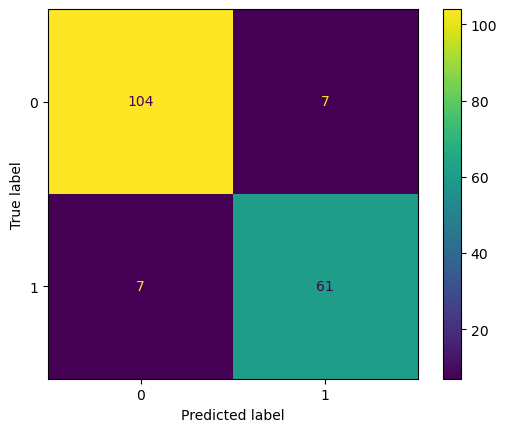

In [38]:
cm_pruned_test = confusion_matrix(y_test_pred, y_test)
print(cm_pruned_test)
ConfusionMatrixDisplay(cm_pruned_test).plot()

In [39]:
print(classification_report(y_test_pred, y_test))

              precision    recall  f1-score   support

           B       0.94      0.94      0.94       111
           M       0.90      0.90      0.90        68

    accuracy                           0.92       179
   macro avg       0.92      0.92      0.92       179
weighted avg       0.92      0.92      0.92       179



Pruned tree now with a better Precision, Recall, and F1-score (0.90) for the Malignant instances and accuracy (92%) in the test set compared to the unpruned tree (0.86 Precision, 0.90 Recall, and 0.88 F1 score, 0.91 accuracy).
Therefore, improved generalization to unseen data.

## KNN

In [40]:
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler

All numerical features need to be normalize into the same range, as kNN distance calculations are sensitive to value ranges.

In [41]:
scaler = StandardScaler()

In [42]:
scaler.fit(X_train)
scaled_train = scaler.transform(X_train)

scaled_Xtrain = pd.DataFrame(scaled_train, columns=X_train.columns)
scaled_Xtrain.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Bratio
0,1.137989,-1.780847,1.282413,1.003867,-0.050698,3.234729,2.781801,2.573041,2.259608,2.275474,2.680179,-0.499952,3.079591,2.692096,-0.176549,1.379370,0.880395,0.777789,1.213184,0.991186,1.842719,-1.285376,2.284254,1.920197,1.282398,2.528249,2.071576,2.290407,2.877226,1.909216,-1.075216
1,1.628773,0.417194,1.580322,1.584635,-0.050699,1.044928,1.451239,2.074672,0.976306,-0.378885,1.338003,-0.714388,0.948437,1.292464,-0.266215,0.871053,0.304798,1.593371,0.278757,0.344206,1.475097,-0.023916,1.336891,1.393902,0.507400,1.045329,0.849276,1.951972,1.205736,0.193418,0.823673
2,-0.758745,0.241270,-0.588617,-0.764023,-0.050693,3.351940,2.021295,1.485454,2.912258,4.931251,0.377660,-0.045904,0.341665,-0.282328,0.799693,2.825074,0.987970,1.262636,4.886362,2.193803,-0.283802,0.125306,-0.245885,-0.543714,3.354863,3.762684,1.954721,2.171048,6.323405,4.872966,-0.098187
3,1.801990,-0.980089,1.791340,1.854893,-0.050701,0.540734,1.459012,1.462093,0.022996,-0.543364,1.382563,-0.724530,1.402451,1.302130,1.656741,-0.003502,0.998055,1.293805,-0.334266,0.561196,1.265898,-1.386908,1.328037,1.166407,0.202626,-0.304738,0.613698,0.735721,-0.907312,-0.398236,1.530273
4,1.213050,-7.919993,1.150009,1.115996,-0.050702,0.097936,0.353881,0.675603,-0.032003,-0.743292,-0.317244,-0.739200,0.200617,0.346646,-0.927366,-0.614275,-0.284619,-0.171125,-0.814509,-0.609910,1.334954,0.303756,1.357550,1.219036,0.498692,0.018786,0.512735,1.199558,0.275250,-0.020235,0.182684


In [43]:
scaled_test = scaler.transform(X_test)

scaled_Xtest = pd.DataFrame(scaled_test, columns=X_test.columns)
scaled_Xtest.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Bratio
0,1.882825,-0.286503,1.700312,1.938271,-0.050704,-0.466910,0.019621,0.576189,0.033996,-0.849636,0.561662,-0.810377,0.316649,0.822148,-0.599311,-0.656163,-0.431786,0.350085,-0.789691,-0.070228,1.763507,-0.350049,1.522822,1.813241,-0.389507,-0.417910,-0.126693,1.090776,-0.254281,0.272306,-1.389751
1,-0.461388,-0.705081,-0.382150,-0.502390,-0.050696,1.232837,0.938188,0.854445,1.042304,1.909649,-0.241185,-0.527300,-0.311946,-0.283271,0.223527,0.496891,0.245035,-0.001429,0.173278,0.548033,-0.170062,-0.297745,-0.112192,-0.248479,2.018210,1.662853,1.247049,0.910982,1.835082,2.210522,-0.047070
2,0.499971,-0.262237,0.487991,0.371348,-0.050702,0.473756,0.183383,0.469507,0.143993,-0.261197,0.416842,-0.355787,0.405003,0.352539,-0.402694,0.902186,-0.084038,0.249653,-0.021550,0.173885,0.835313,0.245298,0.864684,0.697834,0.298412,1.884277,0.597338,1.015232,1.508566,1.136778,0.947114
3,0.520179,0.963165,0.492128,0.376236,-0.050704,-0.065788,0.181310,0.147124,0.162326,-1.316134,0.023101,-0.187172,0.053182,-0.061905,1.037002,0.372925,0.760121,1.479086,1.185883,-0.281634,0.108193,0.303756,0.141619,-0.019456,-0.855377,-0.382236,-0.170631,-0.028779,-0.154465,-1.160265,0.117656
4,-1.311886,-1.364291,-1.301943,-1.086608,-0.050701,-0.722170,-0.723266,-0.706333,0.044995,0.905757,-0.460912,-0.370457,-0.475881,-0.554145,0.978305,-0.585972,-0.385096,0.490344,0.002028,-0.295196,-1.234338,-1.542283,-1.241650,-0.972899,-0.015070,-0.859526,-0.841516,-0.778624,-0.761818,-0.346192,-0.065964


#### Applying Tomek links to balance target classes.

In [44]:
from numpy import mean
from collections import Counter
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from imblearn.under_sampling import TomekLinks
from sklearn.neighbors import KNeighborsClassifier

X = scaled_Xtrain
y = y_train

print('Original dataset:', Counter(y))

smt = SMOTETomek(random_state = 123)
X_resampled, y_resampled = smt.fit_resample(X, y)

print('Resampled dataset:', Counter(y_resampled))

print('\nTarget classes now balanced.')

Original dataset: Counter({'B': 246, 'M': 144})
Resampled dataset: Counter({'M': 243, 'B': 243})

Target classes now balanced.


In [45]:
kNN = KNeighborsClassifier(n_neighbors=20)  # initial k taken as approximately the square root of N (390 instances in training set)

kNN.fit(X_resampled, y_resampled)

KNeighborsClassifier(n_neighbors=20)

In [46]:
y_train_pred1 = kNN.predict(X)

In [47]:
cm_train1 = confusion_matrix(y_train_pred1, y_train)
print(cm_train1)
print(classification_report(y_train_pred1, y_train))

[[236  11]
 [ 10 133]]
              precision    recall  f1-score   support

           B       0.96      0.96      0.96       247
           M       0.92      0.93      0.93       143

    accuracy                           0.95       390
   macro avg       0.94      0.94      0.94       390
weighted avg       0.95      0.95      0.95       390



In [48]:
y_test_pred1 = kNN.predict(scaled_Xtest)

[[105   5]
 [  6  63]]
              precision    recall  f1-score   support

           B       0.95      0.95      0.95       110
           M       0.93      0.91      0.92        69

    accuracy                           0.94       179
   macro avg       0.94      0.93      0.93       179
weighted avg       0.94      0.94      0.94       179



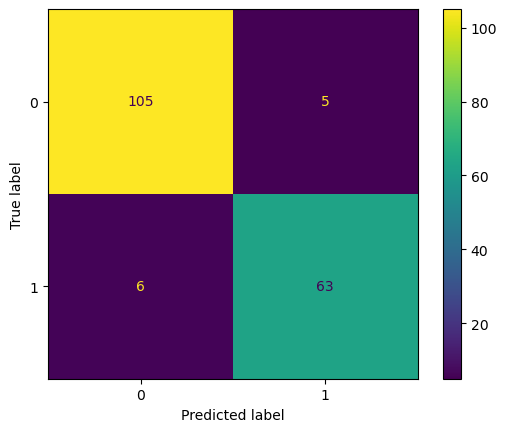

In [49]:
cm_test1 = confusion_matrix(y_test_pred1, y_test)
print(cm_test1)
print(classification_report(y_test_pred1, y_test))
ConfusionMatrixDisplay(cm_test1).plot()

##### Alternatively, applying Edited Nearest Neighbors (ENN) for resampling the imbalanced class distribution

In [50]:
print('Original dataset:', Counter(y))

ENN = SMOTEENN(random_state=123)
resampled_X, resampled_y = ENN.fit_resample(X, y)

print('Resampled dataset:', Counter(resampled_y))

print('\nBetter balanced class distribution')

Original dataset: Counter({'B': 246, 'M': 144})
Resampled dataset: Counter({'M': 218, 'B': 208})

Better balanced class distribution


In [51]:
kNN_2 = KNeighborsClassifier(n_neighbors=20)  # initial k taken as approximately the square root of N (390 instances in training set)
kNN_2.fit(resampled_X, resampled_y)

KNeighborsClassifier(n_neighbors=20)

In [52]:
y_train_pred2 = kNN_2.predict(X)

cm_train2 = confusion_matrix(y_train_pred2, y_train) 
print(cm_train2)
print(classification_report(y_train_pred2, y_train))

[[237  10]
 [  9 134]]
              precision    recall  f1-score   support

           B       0.96      0.96      0.96       247
           M       0.93      0.94      0.93       143

    accuracy                           0.95       390
   macro avg       0.95      0.95      0.95       390
weighted avg       0.95      0.95      0.95       390



In [53]:
y_test_pred2 = kNN_2.predict(scaled_Xtest)

cm_test2 = confusion_matrix(y_test_pred2, y_test)
print(cm_test2)
print(classification_report(y_test_pred2, y_test))
#ConfusionMatrixDisplay(cm_test2).plot()

[[104   2]
 [  7  66]]
              precision    recall  f1-score   support

           B       0.94      0.98      0.96       106
           M       0.97      0.90      0.94        73

    accuracy                           0.95       179
   macro avg       0.95      0.94      0.95       179
weighted avg       0.95      0.95      0.95       179



Although using ENN for balancing the class distribution results in a model with better overall accuracy (0.95), Tomek links result in a model with a marginally higher Malignant class recall (0.91). In the context of predicting cancer, higher recall is more important in assessing model performance since higher TPs and lower FNs are desired for this problem (predicting cancer...it is important for the model to catch as many as possible TPs with little FNs, i.e. high Recall, which is =TP/(TP+FN) ).

----

#### Choosing number of neighbors based on model performance

In [54]:
error = []

for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_resampled, y_resampled)
    pred_i = knn.predict(scaled_Xtest)
    error.append(accuracy_score(y_test, pred_i))

Highest accuracy (96%) can be achieved at a k ~6


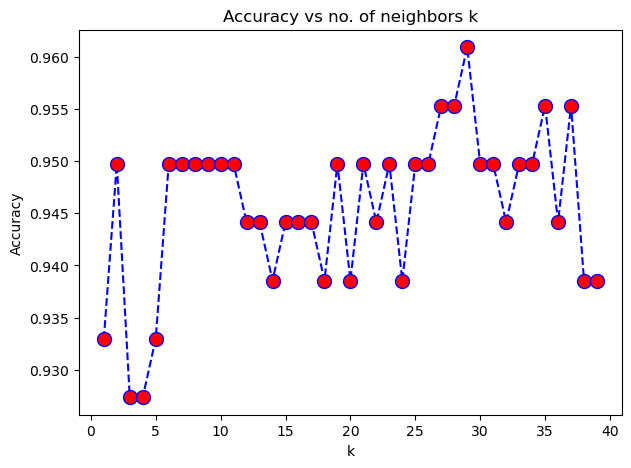

In [55]:
plt.figure(figsize=(7,5))
plt.plot(range(1,40), error, linestyle='dashed', marker='o', markersize=10, color='blue', markerfacecolor='red')
plt.title('Accuracy vs no. of neighbors k')
plt.xlabel('k')
plt.ylabel('Accuracy')

print('Highest accuracy (96%) can be achieved at a k ~6')

#### Applying kNN with the optimal k:

In [56]:
kNN_opt = KNeighborsClassifier(n_neighbors=6)

kNN_opt.fit(X_resampled, y_resampled)  ## using the data resampled with Tomek links

KNeighborsClassifier(n_neighbors=6)

[[107   5]
 [  4  63]]
              precision    recall  f1-score   support

           B       0.96      0.96      0.96       112
           M       0.93      0.94      0.93        67

    accuracy                           0.95       179
   macro avg       0.95      0.95      0.95       179
weighted avg       0.95      0.95      0.95       179



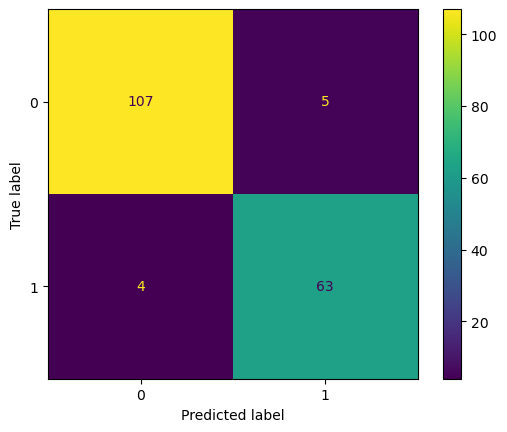

In [57]:
y_test_pred3 = kNN_opt.predict(scaled_Xtest)

cm_test3 = confusion_matrix(y_test_pred3, y_test)
print(cm_test3)
print(classification_report(y_test_pred3, y_test))
ConfusionMatrixDisplay(cm_test3).plot()             

Prediction accuracy over unseen test data marginally improved to 0.95 with 6 neighbors (k), compared to 0.94 with 20 neighbors.
Malignant class recall also improved to 0.94 for k=6, compared to 0.91 at k=20, as well as the F1-score (0.93 from 0.92)

----

### kNN performs better compared to the pruned Decision Tree:

- Malignant recall: kNN (0.94) > DT (0.90) -- for predicting cancer, it is crucial for the model to have a high Malignant recall (i.e. the model correctly predicts a high no. of malignant cases as true positives and is low on false negatives), threfore Malignant recall is a crucial metric for this problem.
- Overall accuracy: kNN (0.95) > DT (0.92)
- Malignant F1-score: kNN (0.93) > DT (0.90)